In [21]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from IPython.display import clear_output
from skimage.util import img_as_ubyte

In [22]:
def imshow_orthogonal_view(sitkImage, origin = None, title=None):
    """
    Display the orthogonal views of a 3D volume from the middle of the volume.

    Parameters
    ----------
    sitkImage : SimpleITK image
        Image to display.
    origin : array_like, optional
        Origin of the orthogonal views, represented by a point [x,y,z].
        If None, the middle of the volume is used.
    title : str, optional
        Super title of the figure.

    Note:
    On the axial and coronal views, patient's left is on the right
    On the sagittal view, patient's anterior is on the left
    """
    data = sitk.GetArrayFromImage(sitkImage)

    if origin is None:
        origin = np.array(data.shape) // 2

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    data = img_as_ubyte(data/np.max(data))
    axes[0].imshow(data[origin[0], ::-1, ::-1], cmap='gray')
    axes[0].set_title('Axial')

    axes[1].imshow(data[::-1, origin[1], ::-1], cmap='gray')
    axes[1].set_title('Coronal')

    axes[2].imshow(data[::-1, ::-1, origin[2]], cmap='gray')
    axes[2].set_title('Sagittal')

    [ax.set_axis_off() for ax in axes]

    if title is not None:
        fig.suptitle(title, fontsize=16)

def overlay_slices(sitkImage0, sitkImage1, origin = None, title=None):
    """
    Overlay the orthogonal views of a two 3D volume from the middle of the volume.
    The two volumes must have the same shape. The first volume is displayed in red,
    the second in green.

    Parameters
    ----------
    sitkImage0 : SimpleITK image
        Image to display in red.
    sitkImage1 : SimpleITK image
        Image to display in green.
    origin : array_like, optional
        Origin of the orthogonal views, represented by a point [x,y,z].
        If None, the middle of the volume is used.
    title : str, optional
        Super title of the figure.

    Note:
    On the axial and coronal views, patient's left is on the right
    On the sagittal view, patient's anterior is on the left
    """
    vol0 = sitk.GetArrayFromImage(sitkImage0)
    vol1 = sitk.GetArrayFromImage(sitkImage1)

    if vol0.shape != vol1.shape:
        raise ValueError('The two volumes must have the same shape.')
    if np.min(vol0) < 0 or np.min(vol1) < 0: # Remove negative values - Relevant for the noisy images
        vol0[vol0 < 0] = 0
        vol1[vol1 < 0] = 0
    if origin is None:
        origin = np.array(vol0.shape) // 2

    sh = vol0.shape
    R = img_as_ubyte(vol0/np.max(vol0))
    G = img_as_ubyte(vol1/np.max(vol1))

    vol_rgb = np.zeros(shape=(sh[0], sh[1], sh[2], 3), dtype=np.uint8)
    vol_rgb[:, :, :, 0] = R
    vol_rgb[:, :, :, 1] = G

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(vol_rgb[origin[0], ::-1, ::-1, :])
    axes[0].set_title('Axial')

    axes[1].imshow(vol_rgb[::-1, origin[1], ::-1, :])
    axes[1].set_title('Coronal')

    axes[2].imshow(vol_rgb[::-1, ::-1, origin[2], :])
    axes[2].set_title('Sagittal')

    [ax.set_axis_off() for ax in axes]

    if title is not None:
        fig.suptitle(title, fontsize=16)

In [23]:
def composite2affine(composite_transform, result_center=None):
    """
    Combine all of the composite transformation's contents to form an equivalent affine transformation.
    Args:
        composite_transform (SimpleITK.CompositeTransform): Input composite transform which contains only
                                                            global transformations, possibly nested.
        result_center (tuple,list): The desired center parameter for the resulting affine transformation.
                                    If None, then set to [0,...]. This can be any arbitrary value, as it is
                                    possible to change the transform center without changing the transformation
                                    effect.
    Returns:
        SimpleITK.AffineTransform: Affine transformation that has the same effect as the input composite_transform.

    Source:
        https://github.com/InsightSoftwareConsortium/SimpleITK-Notebooks/blob/master/Python/22_Transforms.ipynb
    """
    # Flatten the copy of the composite transform, so no nested composites.
    flattened_composite_transform = sitk.CompositeTransform(composite_transform)
    flattened_composite_transform.FlattenTransform()
    tx_dim = flattened_composite_transform.GetDimension()
    A = np.eye(tx_dim)
    c = np.zeros(tx_dim) if result_center is None else result_center
    t = np.zeros(tx_dim)
    for i in range(flattened_composite_transform.GetNumberOfTransforms() - 1, -1, -1):
        curr_tx = flattened_composite_transform.GetNthTransform(i).Downcast()
        # The TranslationTransform interface is different from other
        # global transformations.
        if curr_tx.GetTransformEnum() == sitk.sitkTranslation:
            A_curr = np.eye(tx_dim)
            t_curr = np.asarray(curr_tx.GetOffset())
            c_curr = np.zeros(tx_dim)
        else:
            A_curr = np.asarray(curr_tx.GetMatrix()).reshape(tx_dim, tx_dim)
            c_curr = np.asarray(curr_tx.GetCenter())
            # Some global transformations do not have a translation
            # (e.g. ScaleTransform, VersorTransform)
            get_translation = getattr(curr_tx, "GetTranslation", None)
            if get_translation is not None:
                t_curr = np.asarray(get_translation())
            else:
                t_curr = np.zeros(tx_dim)
        A = np.dot(A_curr, A)
        t = np.dot(A_curr, t + c - c_curr) + t_curr + c_curr - c

    return sitk.AffineTransform(A.flatten(), t, c)

In [24]:
# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []

# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()

# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values(registration_method):
    global metric_values, multires_iterations

    metric_values.append(registration_method.GetMetricValue())
    # Clear the output area (wait=True, to reduce flickering), and plot current data
    clear_output(wait=True)
    # Plot the similarity metric values
    plt.plot(metric_values, 'r')
    plt.plot(multires_iterations, [metric_values[index] for index in multires_iterations], 'b*')
    plt.xlabel('Iteration Number',fontsize=12)
    plt.ylabel('Metric Value',fontsize=12)
    plt.show()

# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))

def command_iteration(method):
    print(
        f"{method.GetOptimizerIteration():3} "
        + f"= {method.GetMetricValue():10.5f} "
        + f": {method.GetOptimizerPosition()}"
    )

Exercise 1

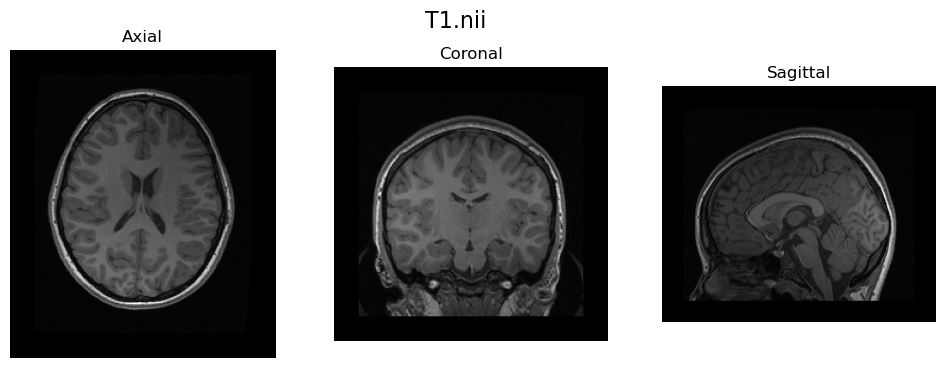

In [25]:
dir_in = 'data/'
vol_sitk = sitk.ReadImage(dir_in + 'ImgT1.nii')

# Display the volume
imshow_orthogonal_view(vol_sitk, title='T1.nii')

Exercise 2

In [26]:
def rotation_matrix(pitch, roll, yaw):
    """
    Compute rotation matrix from pitch, roll, yaw (in degrees).
    Pitch = rotation around x-axis
    Roll  = rotation around y-axis
    Yaw   = rotation around z-axis
    """
    # Convert to radians
    pitch = np.deg2rad(pitch)
    roll  = np.deg2rad(roll)
    yaw   = np.deg2rad(yaw)

    # Rotation around x-axis (pitch)
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(pitch), -np.sin(pitch)],
                   [0, np.sin(pitch),  np.cos(pitch)]])

    # Rotation around y-axis (roll)
    Ry = np.array([[ np.cos(roll), 0, np.sin(roll)],
                   [0, 1, 0],
                   [-np.sin(roll), 0, np.cos(roll)]])

    # Rotation around z-axis (yaw)
    Rz = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                   [np.sin(yaw),  np.cos(yaw), 0],
                   [0, 0, 1]])

    # Combined rotation
    R = Rz @ Ry @ Rx
    return R

Exercise 3

In [27]:
centre_image = np.array(vol_sitk.GetSize()) / 2 - 0.5   # index space
centre_world = vol_sitk.TransformContinuousIndexToPhysicalPoint(centre_image)  # physical space

# Step 4: Create affine transform
transform = sitk.AffineTransform(3)

# Rotation matrix for pitch = 25°
rot_matrix = rotation_matrix(25, 0, 0)[:3, :3]

# IMPORTANT: ITK uses backward mapping, so we must pass the inverse (transpose for pure rotations)
transform.SetMatrix(rot_matrix.T.flatten())

# Set the rotation center
transform.SetCenter(centre_world)

# Step 5: Apply the transform (resample the image)
ImgT1_A = sitk.Resample(vol_sitk, transform)

# Step 6: Save the rotated image
sitk.WriteImage(ImgT1_A, dir_in + "ImgT1_A.nii")


Exercise 4

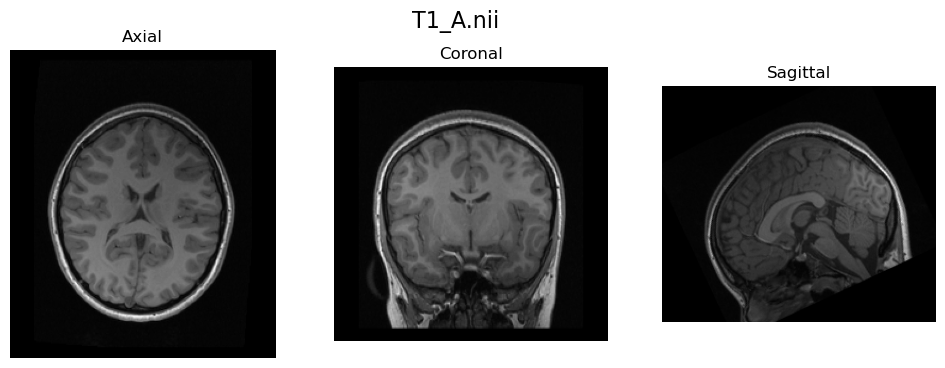

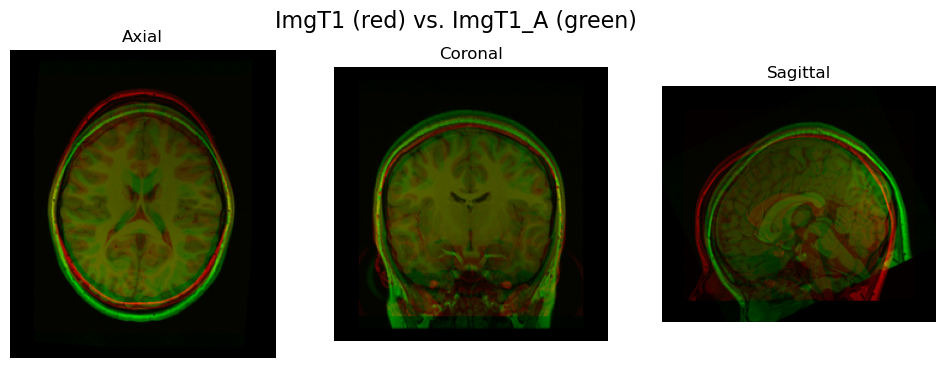

In [28]:
# Show the rotated image in orthogonal views
imshow_orthogonal_view(ImgT1_A, title='T1_A.nii')

# Overlay original (red) vs rotated (green) to compare alignment
overlay_slices(vol_sitk, ImgT1_A, title='ImgT1 (red) vs. ImgT1_A (green)')

Exercise 5

In [29]:
import SimpleITK as sitk
import numpy as np

# Load fixed and moving images
fixed_image = sitk.ReadImage(dir_in + "ImgT1.nii")
moving_image = sitk.ReadImage(dir_in + "ImgT1_A.nii")

# Set up the registration method
R = sitk.ImageRegistrationMethod()

# --- Pyramid step (multi-resolution strategy) ---
# Shrink factors reduce resolution to speed up computation
R.SetShrinkFactorsPerLevel(shrinkFactors=[3])
R.SetSmoothingSigmasPerLevel(smoothingSigmas=[0])
R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

# --- Interpolation step ---
R.SetInterpolator(sitk.sitkLinear)

# --- Metric step ---
# MeanSquares is a simple intensity-based similarity metric
R.SetMetricAsMeanSquares()

# --- Sampling step ---
# Random sampling of voxels to speed up metric evaluation
R.SetMetricSamplingStrategy(R.RANDOM)
R.SetMetricSamplingPercentage(0.50)

# --- Optimization step ---
# Powell optimizer is robust for affine transforms
R.SetOptimizerAsPowell(stepLength=0.1, numberOfIterations=25)

# --- Initial transform ---
# Start with a rigid transform (rotation + translation)
initTransform = sitk.Euler3DTransform()
R.SetInitialTransform(initTransform, inPlace=False)

# --- Optional callbacks for monitoring ---
R.AddCommand(sitk.sitkStartEvent, start_plot)
R.AddCommand(sitk.sitkEndEvent, end_plot)
R.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
R.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(R))

# --- Execute registration ---
tform_reg = R.Execute(fixed_image, moving_image)

# Apply the estimated transformation to the moving image
ImgT1_B = sitk.Resample(moving_image, fixed_image, tform_reg,
                        sitk.sitkLinear, 0.0, moving_image.GetPixelID())

# Save the registered image
sitk.WriteImage(ImgT1_B, dir_in + "ImgT1_B.nii")

# Save the affine transformation matrix to text file
affine = composite2affine(tform_reg)
np.savetxt(dir_in + "A1.txt", np.array(affine.GetMatrix()).reshape(3,3))

Exercise 6

Estimated 3x3 matrix:
 [[ 9.99999998e-01  5.93770530e-05  3.57936587e-05]
 [-3.86932695e-05  9.06355071e-01 -4.22516845e-01]
 [-5.75295691e-05  4.22516842e-01  9.06355071e-01]]
Estimated translation vector: (0.0040891316790225675, 11.168386076602985, 30.61627086175283)
Parameters (Rx, Ry, Rz, Tx, Ty, Tz): (0.4362204117935477, 6.34735446062912e-05, -6.55119111920961e-05, 0.0040891316790225675, 11.168386076602985, 30.61627086175283)
Estimated homogeneous matrix:
 [[ 9.99999998e-01  5.93770530e-05  3.57936587e-05  4.08913168e-03]
 [-3.86932695e-05  9.06355071e-01 -4.22516845e-01  1.11683861e+01]
 [-5.75295691e-05  4.22516842e-01  9.06355071e-01  3.06162709e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Applied homogeneous matrix:
 [[ 1.          0.          0.          0.        ]
 [ 0.          0.90630779  0.42261826  0.        ]
 [ 0.         -0.42261826  0.90630779  0.        ]
 [ 0.          0.          0.          1.        ]]


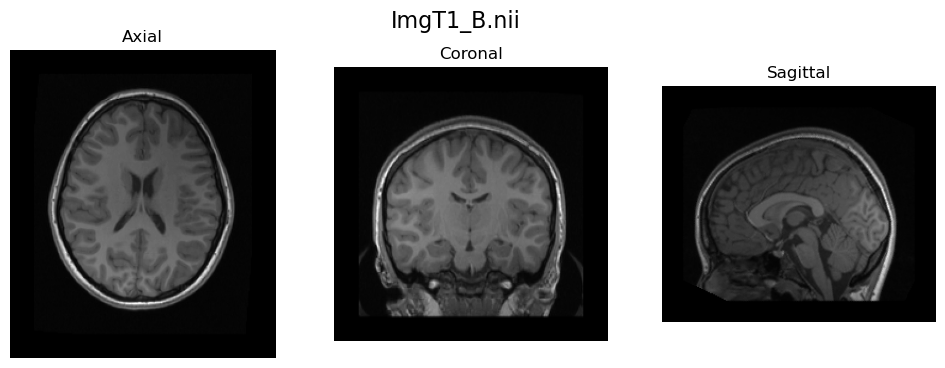

In [30]:
# Step 1: Visualize the registered image
imshow_orthogonal_view(ImgT1_B, title="ImgT1_B.nii")

# Step 2: Extract transformation details
estimated_tform = tform_reg.GetNthTransform(0).GetMatrix()       # 3x3 rotation/scale matrix
estimated_translation = tform_reg.GetNthTransform(0).GetTranslation()  # translation vector
params = tform_reg.GetParameters()  # (Rx, Ry, Rz, Tx, Ty, Tz)

print("Estimated 3x3 matrix:\n", np.reshape(np.array(estimated_tform), (3,3)))
print("Estimated translation vector:", estimated_translation)
print("Parameters (Rx, Ry, Rz, Tx, Ty, Tz):", params)

# Step 3: Convert to homogeneous matrix
def homogeneous_matrix_from_transform(transform):
    """Convert a SimpleITK transform to a homogeneous 4x4 matrix."""
    matrix = np.zeros((4, 4))
    matrix[:3, :3] = np.reshape(np.array(transform.GetMatrix()), (3, 3))
    matrix[:3, 3] = transform.GetTranslation()
    matrix[3, 3] = 1
    return matrix

matrix_estimated = homogeneous_matrix_from_transform(tform_reg.GetNthTransform(0))
matrix_applied   = homogeneous_matrix_from_transform(transform)

print("Estimated homogeneous matrix:\n", matrix_estimated)
print("Applied homogeneous matrix:\n", matrix_applied)

# Step 4: Save and reload the transform
tform_reg.WriteTransform(dir_in + "A1.tfm")
tform_loaded = sitk.ReadTransform(dir_in + "A1.tfm")

Exercise 7

In [32]:
# Step 1: Initialize transform with center of the fixed image
initTransform = sitk.CenteredTransformInitializer(
    fixed_image,
    moving_image,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

# Step 2: Set up registration again
R = sitk.ImageRegistrationMethod()

# Pyramid step
R.SetShrinkFactorsPerLevel(shrinkFactors=[3])
R.SetSmoothingSigmasPerLevel(smoothingSigmas=[0])
R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

# Interpolator
R.SetInterpolator(sitk.sitkLinear)

# Metric
R.SetMetricAsMeanSquares()

# Sampling
R.SetMetricSamplingStrategy(R.RANDOM)
R.SetMetricSamplingPercentage(0.50)

# Optimizer
R.SetOptimizerAsPowell(stepLength=0.1, numberOfIterations=25)

# Use the centered initialization
R.SetInitialTransform(initTransform, inPlace=False)

# Optional callbacks for monitoring
R.AddCommand(sitk.sitkStartEvent, start_plot)
R.AddCommand(sitk.sitkEndEvent, end_plot)
R.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
R.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(R))

# Step 3: Execute registration
tform_reg_centered = R.Execute(fixed_image, moving_image)

# Step 4: Apply the estimated transformation
ImgT1_B_centered = sitk.Resample(moving_image, fixed_image, tform_reg_centered,
                                 sitk.sitkLinear, 0.0, moving_image.GetPixelID())

# Step 5: Save the new registered image
sitk.WriteImage(ImgT1_B_centered, dir_in + "ImgT1_B_centered.nii")

# Extract the first transform from the composite
first_transform = tform_reg_centered.GetNthTransform(0)

# Now you can safely access its matrix and translation
estimated_matrix_centered = np.reshape(np.array(first_transform.GetMatrix()), (3,3))
estimated_translation_centered = first_transform.GetTranslation()

print("Estimated matrix (centered init):\n", estimated_matrix_centered)
print("Estimated translation (centered init):", estimated_translation_centered)


Estimated matrix (centered init):
 [[ 9.99999999e-01  4.36877716e-05  1.05915923e-05]
 [-3.51181164e-05  9.06304008e-01 -4.22626365e-01]
 [-2.80628067e-05  4.22626364e-01  9.06304008e-01]]
Estimated translation (centered init): (0.0008778727130404832, 0.0008944177243718923, 0.0006842577298330568)


Exercise 8

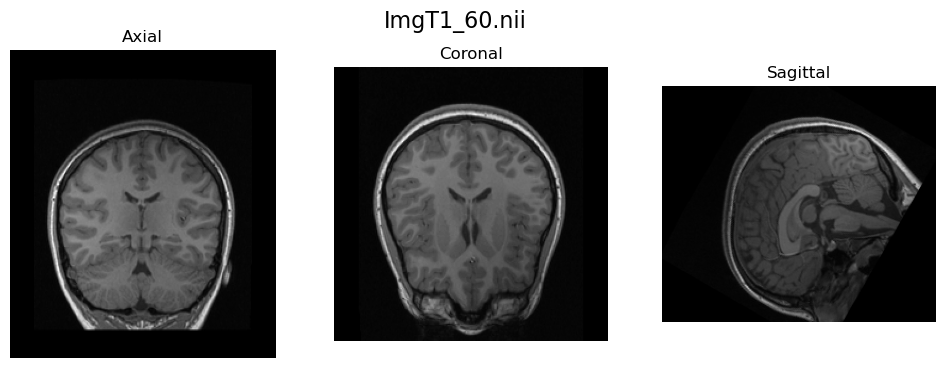

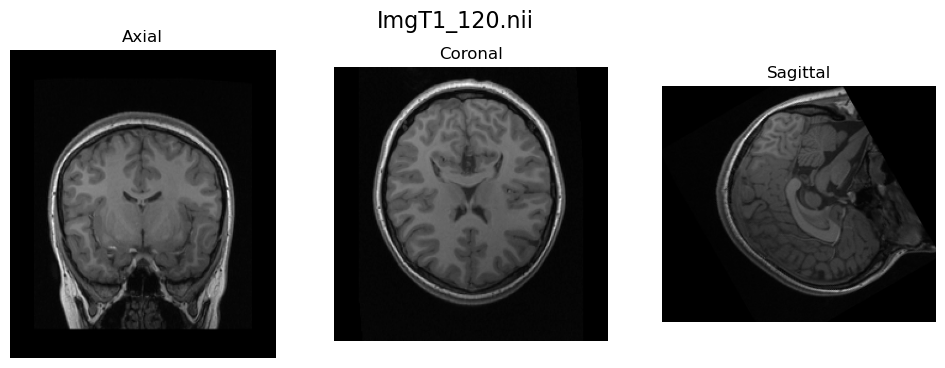

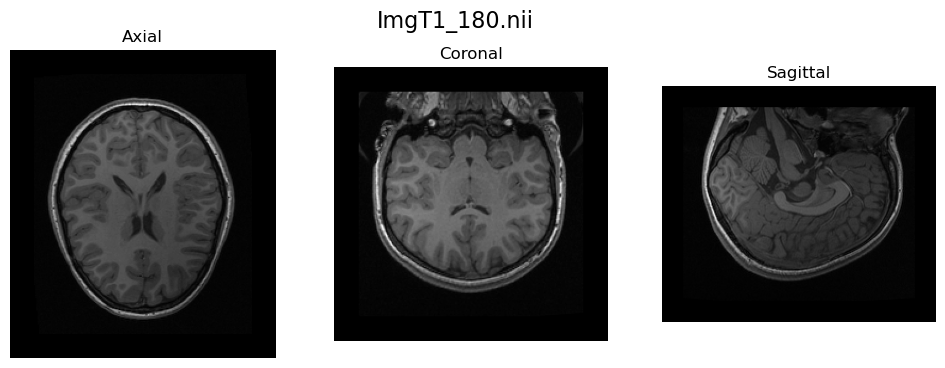

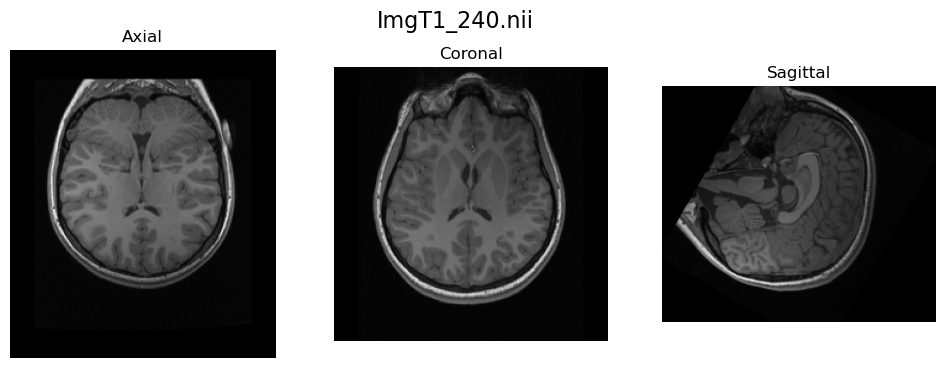

In [33]:
# Load the original image
vol_sitk = sitk.ReadImage(dir_in + "ImgT1.nii")

# Compute the center in world coordinates
centre_image = np.array(vol_sitk.GetSize()) / 2 - 0.5
centre_world = vol_sitk.TransformContinuousIndexToPhysicalPoint(centre_image)

# Rotation angles (in degrees)
angles = [60, 120, 180, 240]

# Loop through each angle, apply rotation, and save
for angle in angles:
    # Create affine transform
    transform = sitk.AffineTransform(3)

    # Rotation matrix (pitch rotation around x-axis)
    rot_matrix = rotation_matrix(angle, 0, 0)[:3, :3]

    # ITK uses backward mapping → pass transpose
    transform.SetMatrix(rot_matrix.T.flatten())
    transform.SetCenter(centre_world)

    # Apply transform
    rotated_img = sitk.Resample(vol_sitk, transform)

    # Save rotated image
    filename = dir_in + f"ImgT1_{angle}.nii"
    sitk.WriteImage(rotated_img, filename)

    # Show in ortho-view
    imshow_orthogonal_view(rotated_img, title=f"ImgT1_{angle}.nii")

Exercise 9

In [37]:
# Load fixed image (120° rotation)
fixed_image = sitk.ReadImage(dir_in + "ImgT1_120.nii")

# Moving images (other rotations)
moving_files = {
    "Ex9_60.tfm": "ImgT1_60.nii",
    "Ex10_180.tfm": "ImgT1_180.nii",
    "Ex10_240.tfm": "ImgT1_240.nii"
}

# Helper: run registration and save results
def run_registration_large_rotation(fixed_image, moving_file, transform_name):
    moving_image = sitk.ReadImage(dir_in + moving_file)

    R = sitk.ImageRegistrationMethod()

    # Multi-resolution pyramid (coarse-to-fine)
    R.SetShrinkFactorsPerLevel([4, 2, 1])
    R.SetSmoothingSigmasPerLevel([2.0, 1.0, 0.0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    # Interpolator and metric
    R.SetInterpolator(sitk.sitkLinear)
    R.SetMetricAsMeanSquares()

    # Sampling
    R.SetMetricSamplingStrategy(R.RANDOM)
    R.SetMetricSamplingPercentage(0.50)

    # Optimizer tuned for large rotations
    R.SetOptimizerAsPowell(stepLength=10.0, numberOfIterations=50)

    # Centered initialization to minimize translation
    initTransform = sitk.CenteredTransformInitializer(
        fixed_image, moving_image, sitk.Euler3DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    R.SetInitialTransform(initTransform, inPlace=False)

    # Optional monitoring (if you already defined these callbacks)
    R.AddCommand(sitk.sitkStartEvent, start_plot)
    R.AddCommand(sitk.sitkEndEvent, end_plot)
    R.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
    R.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(R))

    # Execute registration
    tform_reg = R.Execute(fixed_image, moving_image)

    # Reslice to the fixed image geometry
    resliced = sitk.Resample(
        moving_image, fixed_image, tform_reg,
        sitk.sitkLinear, 0.0, moving_image.GetPixelID()
    )

    # Save resliced image and transform
    out_name = moving_file.replace(".nii", "_resliced.nii")
    sitk.WriteImage(resliced, dir_in + out_name)
    tform_reg.WriteTransform(dir_in + transform_name)

    # Inspect (optional)
    tr = tform_reg.GetNthTransform(0)
    print(f"{moving_file} → {transform_name}")
    print("Matrix:\n", np.reshape(np.array(tr.GetMatrix()), (3,3)))
    print("Translation:", tr.GetTranslation(), "\n")

# Run for each moving image
for tfm_name, mov_file in moving_files.items():
    run_registration_large_rotation(fixed_image, mov_file, tfm_name)

ImgT1_240.nii → Ex10_240.tfm
Matrix:
 [[-0.99980846 -0.00782907 -0.01793742]
 [ 0.00743096 -0.99972695  0.02215429]
 [-0.01810597  0.02201676  0.99959364]]
Translation: (-2.961269316899205, -2.0539524265035225, -3.978613045311376) 

